# Clasificacion de Imagenes con CNN — CIFAR-10

## Caso de Estudio: Sistema de Reconocimiento Visual para Ruteo Automatico

Una empresa de logistica necesita clasificar automaticamente el contenido de paquetes a partir de imagenes para optimizar el ruteo y la clasificacion en almacen.

**Dataset:** CIFAR-10 (60,000 imagenes RGB 32×32, 10 categorias)  
**Clases:** airplane, automobile, bird, cat, deer, dog, frog, horse, ship, truck  
**Objetivo:** Maximizar accuracy sobre imagenes reales a color  
**Metricas:** Accuracy, Loss, Matriz de Confusion, Tiempo de inferencia

In [11]:
import os
import warnings
import json
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from itertools import product as iter_product

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, callbacks, regularizers
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report

warnings.filterwarnings('ignore')
np.random.seed(42)
tf.random.set_seed(42)
random.seed(42)

CLASS_NAMES = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']

print(f'TensorFlow: {tf.__version__}')
print(f'GPU disponible: {len(tf.config.list_physical_devices("GPU")) > 0}')
print(f'Clases CIFAR-10: {CLASS_NAMES}')

TensorFlow: 2.18.0
GPU disponible: False
Clases CIFAR-10: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


## 2. Data Processing

### 2.1 Carga del Dataset CIFAR-10

In [12]:
(X_raw_train, y_raw_train), (X_raw_test, y_raw_test) = cifar10.load_data()

# Las etiquetas vienen con shape (N, 1), aplanar a (N,)
y_raw_train = y_raw_train.flatten()
y_raw_test  = y_raw_test.flatten()

print('=' * 50)
print('CIFAR-10 Dataset cargado correctamente')
print('=' * 50)
print(f'Train: {X_raw_train.shape}  labels: {y_raw_train.shape}')
print(f'Test:  {X_raw_test.shape}   labels: {y_raw_test.shape}')
print(f'Rango pixeles: [{X_raw_train.min()}, {X_raw_train.max()}]')
print(f'Tipo de dato: {X_raw_train.dtype}')
print(f'Canales: RGB (3 canales)')

CIFAR-10 Dataset cargado correctamente
Train: (50000, 32, 32, 3)  labels: (50000,)
Test:  (10000, 32, 32, 3)   labels: (10000,)
Rango pixeles: [0, 255]
Tipo de dato: uint8
Canales: RGB (3 canales)


### 2.2 Analisis Exploratorio y Visualizacion

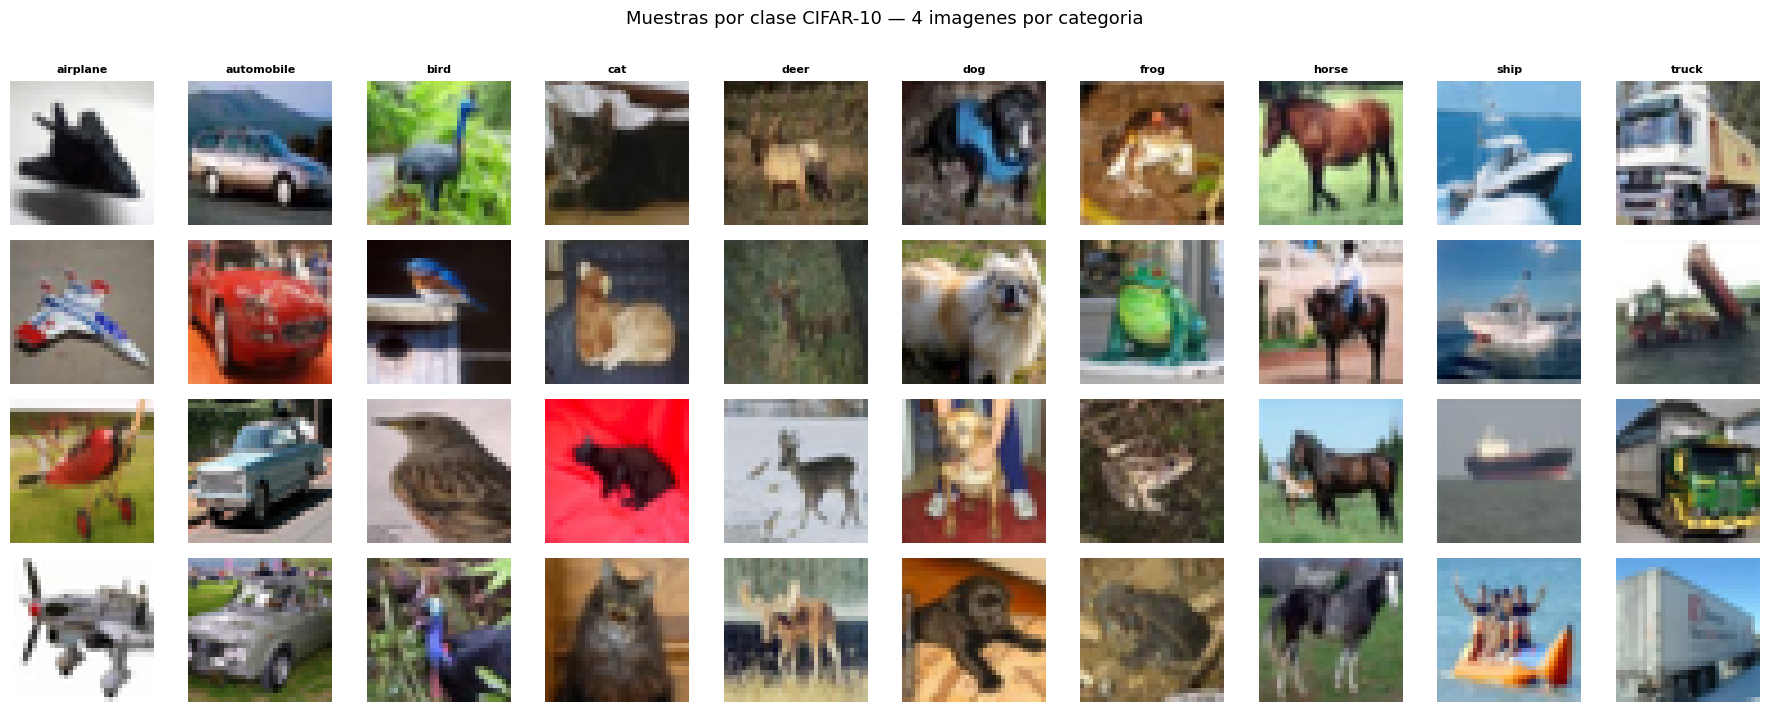

In [13]:
# Visualizar 4 muestras por clase
fig, axes = plt.subplots(4, 10, figsize=(18, 7))
for cls in range(10):
    idxs = np.where(y_raw_train == cls)[0][:4]
    for row, idx in enumerate(idxs):
        axes[row, cls].imshow(X_raw_train[idx])
        if row == 0:
            axes[row, cls].set_title(CLASS_NAMES[cls], fontsize=8, fontweight='bold')
        axes[row, cls].axis('off')

plt.suptitle('Muestras por clase CIFAR-10 — 4 imagenes por categoria', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

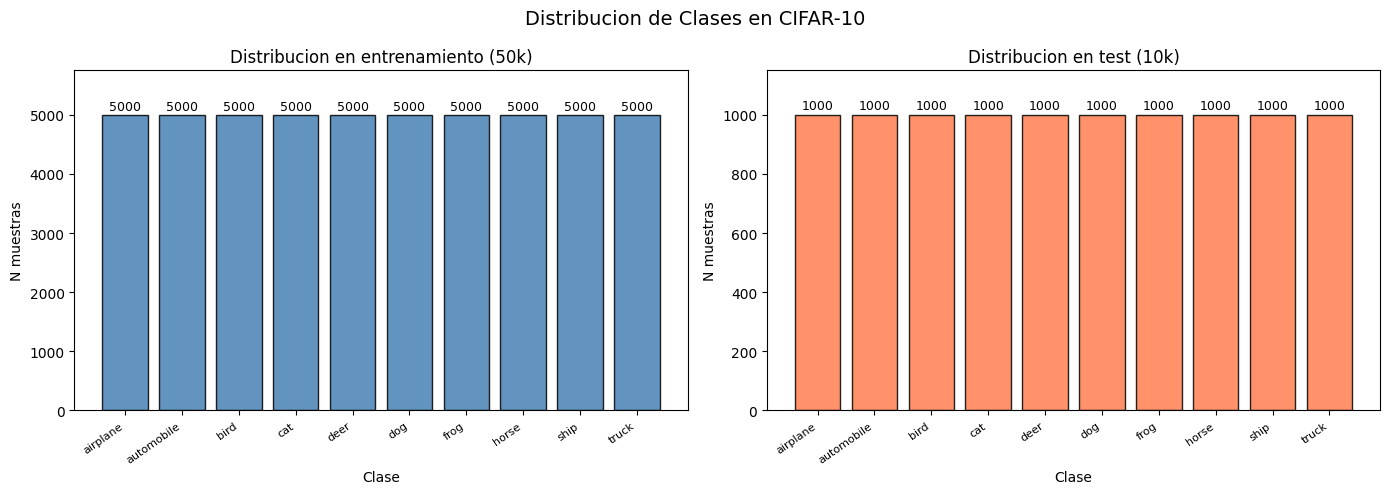

Analisis de desbalance:
Clase           Train   %Train     Test    %Test
------------------------------------------------
airplane         5000   10.00%     1000   10.00%
automobile       5000   10.00%     1000   10.00%
bird             5000   10.00%     1000   10.00%
cat              5000   10.00%     1000   10.00%
deer             5000   10.00%     1000   10.00%
dog              5000   10.00%     1000   10.00%
frog             5000   10.00%     1000   10.00%
horse            5000   10.00%     1000   10.00%
ship             5000   10.00%     1000   10.00%
truck            5000   10.00%     1000   10.00%

Coeficiente de variacion (train): 0.00%
Dataset perfectamente balanceado — no es necesario oversampling.


In [14]:
# Distribucion de clases
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

unique_tr, counts_tr = np.unique(y_raw_train, return_counts=True)
bars = axes[0].bar(range(10), counts_tr, color='steelblue', edgecolor='black', alpha=0.85)
for bar, count in zip(bars, counts_tr):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
                 str(count), ha='center', va='bottom', fontsize=9)
axes[0].set_title('Distribucion en entrenamiento (50k)')
axes[0].set_xlabel('Clase')
axes[0].set_ylabel('N muestras')
axes[0].set_xticks(range(10))
axes[0].set_xticklabels(CLASS_NAMES, rotation=35, ha='right', fontsize=8)
axes[0].set_ylim(0, max(counts_tr) * 1.15)

unique_te, counts_te = np.unique(y_raw_test, return_counts=True)
bars2 = axes[1].bar(range(10), counts_te, color='coral', edgecolor='black', alpha=0.85)
for bar, count in zip(bars2, counts_te):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
                 str(count), ha='center', va='bottom', fontsize=9)
axes[1].set_title('Distribucion en test (10k)')
axes[1].set_xlabel('Clase')
axes[1].set_ylabel('N muestras')
axes[1].set_xticks(range(10))
axes[1].set_xticklabels(CLASS_NAMES, rotation=35, ha='right', fontsize=8)
axes[1].set_ylim(0, max(counts_te) * 1.15)

plt.suptitle('Distribucion de Clases en CIFAR-10', fontsize=14)
plt.tight_layout()
plt.show()

print('Analisis de desbalance:')
print(f'{"Clase":<12} {"Train":>8} {"%Train":>8} {"Test":>8} {"%Test":>8}')
print('-' * 48)
for d in range(10):
    tr = counts_tr[d]; te = counts_te[d]
    print(f'{CLASS_NAMES[d]:<12} {tr:>8} {tr/len(y_raw_train)*100:>7.2f}% {te:>8} {te/len(y_raw_test)*100:>7.2f}%')

cv_train = counts_tr.std() / counts_tr.mean() * 100
print(f'\nCoeficiente de variacion (train): {cv_train:.2f}%')
if cv_train < 5:
    print('Dataset perfectamente balanceado — no es necesario oversampling.')
else:
    print('Considerar oversampling o augmentation focalizado.')

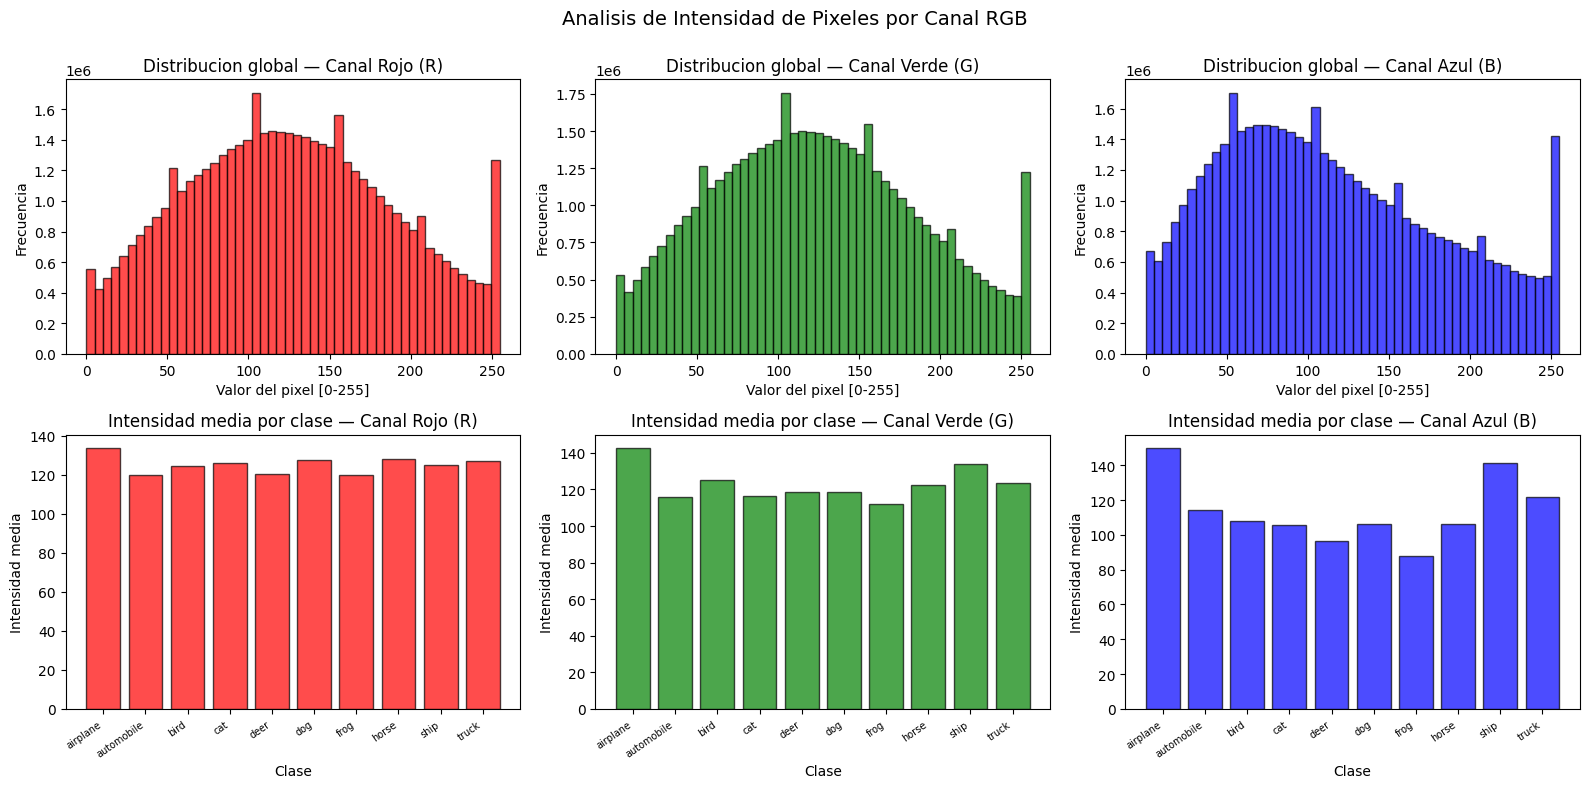

Media global por canal:  R=125.3  G=123.0  B=113.9
Std global por canal:    R=63.0   G=62.1   B=66.7


In [15]:
# Analisis de intensidad de pixeles por canal RGB
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
channel_names = ['Rojo (R)', 'Verde (G)', 'Azul (B)']
channel_colors = ['red', 'green', 'blue']

for ch in range(3):
    # Histograma global del canal
    axes[0, ch].hist(X_raw_train[:, :, :, ch].flatten(),
                     bins=50, color=channel_colors[ch], alpha=0.7, edgecolor='black')
    axes[0, ch].set_title(f'Distribucion global — Canal {channel_names[ch]}')
    axes[0, ch].set_xlabel('Valor del pixel [0-255]')
    axes[0, ch].set_ylabel('Frecuencia')

    # Intensidad media por clase en este canal
    means = [X_raw_train[y_raw_train == c, :, :, ch].mean() for c in range(10)]
    axes[1, ch].bar(range(10), means, color=channel_colors[ch], alpha=0.7, edgecolor='black')
    axes[1, ch].set_title(f'Intensidad media por clase — Canal {channel_names[ch]}')
    axes[1, ch].set_xlabel('Clase')
    axes[1, ch].set_ylabel('Intensidad media')
    axes[1, ch].set_xticks(range(10))
    axes[1, ch].set_xticklabels(CLASS_NAMES, rotation=35, ha='right', fontsize=7)

plt.suptitle('Analisis de Intensidad de Pixeles por Canal RGB', fontsize=14)
plt.tight_layout()
plt.show()

print(f'Media global por canal:  R={X_raw_train[:,:,:,0].mean():.1f}  G={X_raw_train[:,:,:,1].mean():.1f}  B={X_raw_train[:,:,:,2].mean():.1f}')
print(f'Std global por canal:    R={X_raw_train[:,:,:,0].std():.1f}   G={X_raw_train[:,:,:,1].std():.1f}   B={X_raw_train[:,:,:,2].std():.1f}')

### 2.3 Preprocesamiento

- **Normalizacion:** dividir por 255 → rango [0, 1]
- **Shape:** ya es `(N, 32, 32, 3)` — no necesita reshape
- **One-hot encoding:** etiquetas a vectores categoricos
- **Split:** 70% train / 15% val / 15% test (estratificado)
- **Augmentation:** rotaciones, flips horizontales, zoom, traslaciones

In [16]:
# Concatenar todo para split limpio 70/15/15
X_all = np.concatenate([X_raw_train, X_raw_test], axis=0).astype('float32') / 255.0
y_all = np.concatenate([y_raw_train, y_raw_test], axis=0)
y_all_cat = to_categorical(y_all, num_classes=10)

print(f'Total muestras: {len(X_all)}')
print(f'Shape X: {X_all.shape}  (N, altura, anchura, canales_RGB)')
print(f'Shape y (one-hot): {y_all_cat.shape}')
print(f'Rango de pixeles: [{X_all.min():.3f}, {X_all.max():.3f}]')

Total muestras: 60000
Shape X: (60000, 32, 32, 3)  (N, altura, anchura, canales_RGB)
Shape y (one-hot): (60000, 10)
Rango de pixeles: [0.000, 1.000]


In [17]:
# Split estratificado 70 / 15 / 15
X_train, X_temp, y_train, y_temp = train_test_split(
    X_all, y_all_cat,
    test_size=0.30,
    random_state=42,
    stratify=y_all
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.50,
    random_state=42,
    stratify=np.argmax(y_temp, axis=1)
)

total = len(X_all)
print(f'{"Conjunto":12} {"Muestras":>10} {"Porcentaje":>12}')
print('-' * 36)
print(f'{"Train":12} {len(X_train):>10} {len(X_train)/total*100:>11.1f}%')
print(f'{"Validacion":12} {len(X_val):>10} {len(X_val)/total*100:>11.1f}%')
print(f'{"Test":12} {len(X_test):>10} {len(X_test)/total*100:>11.1f}%')

print('\nVerificacion de estratificacion:')
for name, y in [('Train', y_train), ('Val', y_val), ('Test', y_test)]:
    counts = np.bincount(np.argmax(y, axis=1))
    cv = counts.std() / counts.mean() * 100
    print(f'  {name}: CV={cv:.2f}% — {"OK" if cv < 5 else "REVISAR"}')

Conjunto       Muestras   Porcentaje
------------------------------------
Train             42000        70.0%
Validacion         9000        15.0%
Test               9000        15.0%

Verificacion de estratificacion:
  Train: CV=0.00% — OK
  Val: CV=0.00% — OK
  Test: CV=0.00% — OK


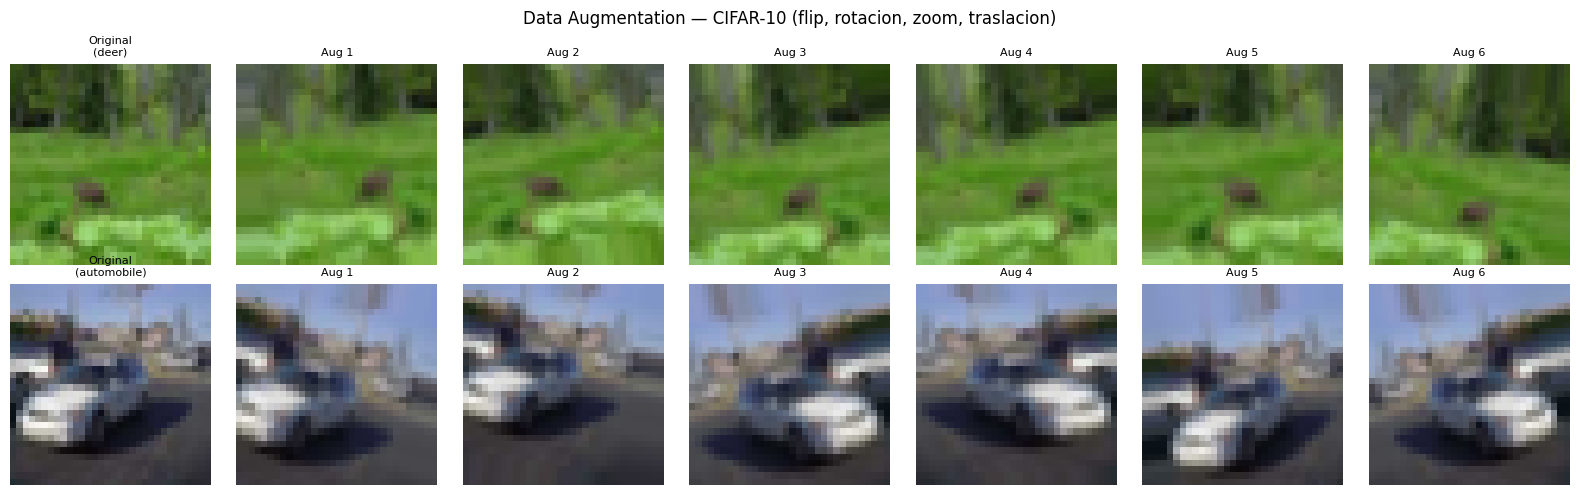

In [18]:
# Data Augmentation — mas agresiva para CIFAR-10 (imagenes naturales)
datagen = ImageDataGenerator(
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    zoom_range=0.1,
    fill_mode='nearest'
)
datagen.fit(X_train)

# Visualizar augmentaciones
fig, axes = plt.subplots(2, 7, figsize=(16, 5))
for row, sample_idx in enumerate([0, 500]):
    sample = X_train[sample_idx:sample_idx+1]
    label = np.argmax(y_train[sample_idx])
    aug_flow = datagen.flow(sample, batch_size=1)

    axes[row, 0].imshow(sample[0])
    axes[row, 0].set_title(f'Original\n({CLASS_NAMES[label]})', fontsize=8)
    axes[row, 0].axis('off')

    for col in range(1, 7):
        aug_img = next(aug_flow)[0]
        axes[row, col].imshow(np.clip(aug_img, 0, 1))
        axes[row, col].set_title(f'Aug {col}', fontsize=8)
        axes[row, col].axis('off')

plt.suptitle('Data Augmentation — CIFAR-10 (flip, rotacion, zoom, traslacion)', fontsize=12)
plt.tight_layout()
plt.show()

## 3-4. Planificacion y Construccion del Modelo

CIFAR-10 es significativamente mas dificil que MNIST (imagenes a color, objetos reales con fondo variable).
Se usa una arquitectura mas profunda con:
- 4 bloques Conv → BN → Conv → BN → MaxPool
- L2 regularization en capas densas
- Dropout progresivo

**Accuracy esperada:** 80-88% (vs 99%+ en MNIST)

In [19]:
def build_cnn(filters1=32, filters2=64, filters3=128, filters4=256,
              dense_units=256, dropout1=0.3, dropout2=0.5,
              lr=1e-3, l2_reg=1e-4, use_batch_norm=True):
    """CNN configurable para CIFAR-10 (32x32x3)."""
    reg = regularizers.l2(l2_reg)
    model = keras.Sequential(name='CNN_CIFAR10')
    model.add(layers.Input(shape=(32, 32, 3)))

    # Bloque 1
    model.add(layers.Conv2D(filters1, (3, 3), activation='relu', padding='same'))
    if use_batch_norm:
        model.add(layers.BatchNormalization())
    model.add(layers.Conv2D(filters1, (3, 3), activation='relu', padding='same'))
    if use_batch_norm:
        model.add(layers.BatchNormalization())
    model.add(layers.MaxPooling2D((2, 2)))
    model.add(layers.Dropout(dropout1))

    # Bloque 2
    model.add(layers.Conv2D(filters2, (3, 3), activation='relu', padding='same'))
    if use_batch_norm:
        model.add(layers.BatchNormalization())
    model.add(layers.Conv2D(filters2, (3, 3), activation='relu', padding='same'))
    if use_batch_norm:
        model.add(layers.BatchNormalization())
    model.add(layers.MaxPooling2D((2, 2)))
    model.add(layers.Dropout(dropout1))

    # Bloque 3
    model.add(layers.Conv2D(filters3, (3, 3), activation='relu', padding='same'))
    if use_batch_norm:
        model.add(layers.BatchNormalization())
    model.add(layers.Conv2D(filters3, (3, 3), activation='relu', padding='same'))
    if use_batch_norm:
        model.add(layers.BatchNormalization())
    model.add(layers.MaxPooling2D((2, 2)))
    model.add(layers.Dropout(dropout1 + 0.1))

    # Clasificador
    model.add(layers.Flatten())
    model.add(layers.Dense(dense_units, activation='relu', kernel_regularizer=reg))
    model.add(layers.Dropout(dropout2))
    model.add(layers.Dense(10, activation='softmax'))

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=lr),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return model


base_model = build_cnn()
base_model.summary()
print(f'\nTotal parametros: {base_model.count_params():,}')

Model: "CNN_CIFAR10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 8, 8, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         2,57

 Total params: 815,914 (3.11 MB)

 Trainable params: 815,018 (3.11 MB)

 Non-trainable params: 896 (3.50 KB)


Total parametros: 815,914


In [20]:
def get_callbacks(patience=7, min_delta=1e-4):
    return [
        callbacks.EarlyStopping(
            monitor='val_accuracy', patience=patience,
            min_delta=min_delta, restore_best_weights=True, verbose=1
        ),
        callbacks.ReduceLROnPlateau(
            monitor='val_loss', factor=0.5, patience=4,
            min_lr=1e-6, verbose=0
        )
    ]


BATCH_SIZE = 64
EPOCHS_FULL = 60

print('Entrenando modelo base...')
history_base = base_model.fit(
    datagen.flow(X_train, y_train, batch_size=BATCH_SIZE),
    steps_per_epoch=len(X_train) // BATCH_SIZE,
    epochs=EPOCHS_FULL,
    validation_data=(X_val, y_val),
    callbacks=get_callbacks(patience=7),
    verbose=1
)

Entrenando modelo base...
Epoch 1/60
656/656 ━━━━━━━━━━━━━━━━━━━━ 71s 103ms/step - accuracy: 0.2724 - loss: 2.2427 - val_accuracy: 0.3919 - val_loss: 1.7892 - learning_rate: 0.0010
Epoch 2/60
656/656 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.3906 - loss: 1.5428 - val_accuracy: 0.3957 - val_loss: 1.7844 - learning_rate: 0.0010
Epoch 3/60
656/656 ━━━━━━━━━━━━━━━━━━━━ 64s 98ms/step - accuracy: 0.4359 - loss: 1.5961 - val_accuracy: 0.4671 - val_loss: 1.7459 - learning_rate: 0.0010
Epoch 4/60
656/656 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.4375 - loss: 1.5416 - val_accuracy: 0.4721 - val_loss: 1.6768 - learning_rate: 0.0010
Epoch 5/60
656/656 ━━━━━━━━━━━━━━━━━━━━ 72s 110ms/step - accuracy: 0.5230 - loss: 1.3934 - val_accuracy: 0.6136 - val_loss: 1.1904 - learning_rate: 0.0010
Epoch 6/60
656/656 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.4688 - loss: 1.4357 - val_accuracy: 0.6082 - val_loss: 1.2116 - learning_rate: 0.0010
Epoch 7/60
656/656 ━━━━━━━━━━━━━━━━━━━━ 68s 103ms/step

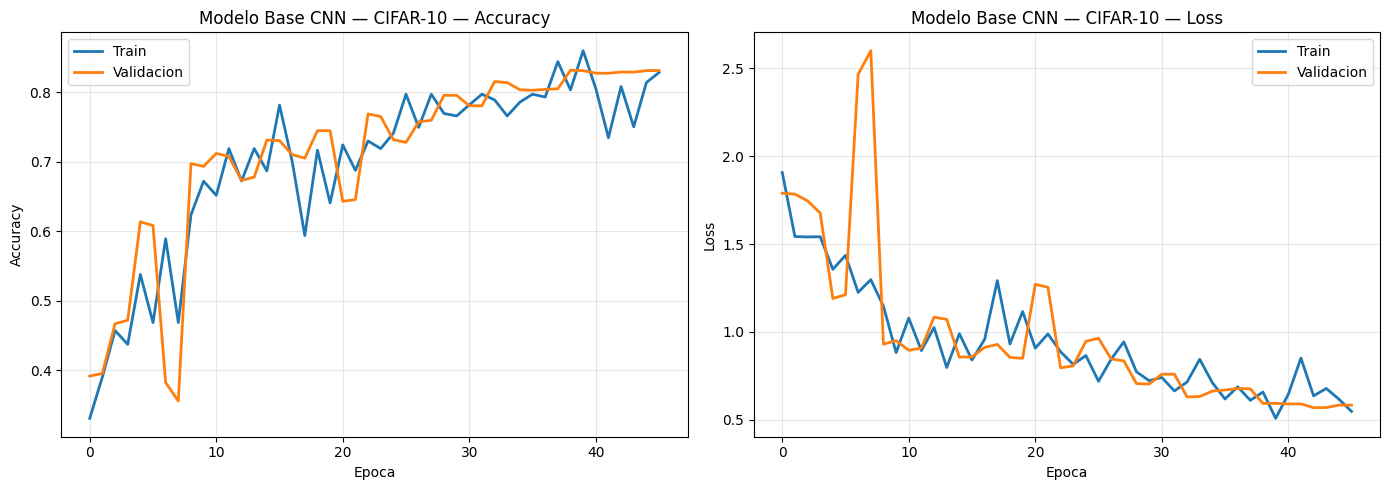

Epocas entrenadas:  46
Mejor Val Accuracy: 0.8313 (83.13%)
Mejor Val Loss:     0.568811
Gap train-val:      -0.0032 (aceptable)


In [21]:
def plot_history(history, title='Curvas de Entrenamiento'):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    axes[0].plot(history.history['accuracy'], label='Train', linewidth=2)
    axes[0].plot(history.history['val_accuracy'], label='Validacion', linewidth=2)
    axes[0].set_title(f'{title} — Accuracy')
    axes[0].set_xlabel('Epoca')
    axes[0].set_ylabel('Accuracy')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    axes[1].plot(history.history['loss'], label='Train', linewidth=2)
    axes[1].plot(history.history['val_loss'], label='Validacion', linewidth=2)
    axes[1].set_title(f'{title} — Loss')
    axes[1].set_xlabel('Epoca')
    axes[1].set_ylabel('Loss')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    best_val_acc = max(history.history['val_accuracy'])
    best_val_loss = min(history.history['val_loss'])
    n_epochs = len(history.history['accuracy'])
    # Gap train-val para detectar overfitting
    last_train = history.history['accuracy'][-1]
    gap = last_train - best_val_acc
    print(f'Epocas entrenadas:  {n_epochs}')
    print(f'Mejor Val Accuracy: {best_val_acc:.4f} ({best_val_acc*100:.2f}%)')
    print(f'Mejor Val Loss:     {best_val_loss:.6f}')
    print(f'Gap train-val:      {gap:.4f} ({"overfitting" if gap > 0.05 else "aceptable"})')


plot_history(history_base, 'Modelo Base CNN — CIFAR-10')

## Busqueda de Hiperparametros

Se utiliza **Grid Search** como estrategia de busqueda exhaustiva:

| Estrategia | Enfoque | Ventaja |
|---|---|---|
| **Grid Search** | Prueba **todas** las combinaciones de una rejilla pequena | Garantiza el optimo local dentro del espacio definido |

**Grid Search:** `filters1` x `dropout1` x `lr` = 2x2x2 = **8 combinaciones**

In [22]:
# Configuracion de la busqueda
SEARCH_EPOCHS = 15      # epocas por config durante busqueda
SEARCH_BATCH  = 64
SEARCH_SIZE   = int(len(X_train) * 0.35)  # 35% del train para velocidad

X_search = X_train[:SEARCH_SIZE]
y_search = y_train[:SEARCH_SIZE]

print(f'Subconjunto de busqueda: {SEARCH_SIZE} muestras de {len(X_train)}')
print(f'Epocas por configuracion: {SEARCH_EPOCHS}')


def train_and_eval(params, epochs=SEARCH_EPOCHS):
    """Entrena con params dados y devuelve (val_accuracy, val_loss)."""
    tf.keras.backend.clear_session()
    model = build_cnn(
        filters1=int(params.get('filters1', 32)),
        filters2=int(params.get('filters2', 64)),
        filters3=int(params.get('filters3', 128)),
        filters4=int(params.get('filters4', 256)),
        dense_units=int(params.get('dense_units', 256)),
        dropout1=float(params.get('dropout1', 0.3)),
        dropout2=float(params.get('dropout2', 0.5)),
        lr=float(params.get('learning_rate', 1e-3)),
        use_batch_norm=True
    )
    early = callbacks.EarlyStopping(
        monitor='val_accuracy', patience=4,
        restore_best_weights=True, verbose=0
    )
    # Augmentation tambien durante busqueda
    aug = ImageDataGenerator(horizontal_flip=True, width_shift_range=0.1,
                             height_shift_range=0.1, rotation_range=10)
    hist = model.fit(
        aug.flow(X_search, y_search, batch_size=SEARCH_BATCH),
        steps_per_epoch=len(X_search) // SEARCH_BATCH,
        epochs=epochs,
        validation_data=(X_val, y_val),
        callbacks=[early],
        verbose=0
    )
    val_acc  = max(hist.history['val_accuracy'])
    val_loss = min(hist.history['val_loss'])
    return val_acc, val_loss

Subconjunto de busqueda: 14699 muestras de 42000
Epocas por configuracion: 15


In [23]:
# ============================================================
# GRID SEARCH — Busqueda exhaustiva
# ============================================================
grid_param_space = {
    'filters1':      [32, 64],
    'dropout1':      [0.25, 0.35],
    'learning_rate': [1e-3, 5e-4],
}

grid_keys   = list(grid_param_space.keys())
grid_combos = list(iter_product(*grid_param_space.values()))
n_grid      = len(grid_combos)

print(f'Grid Search: {n_grid} combinaciones exhaustivas')
print(f'Hiperparametros: {grid_keys}\n')

grid_results = []
for i, combo in enumerate(grid_combos):
    params = dict(zip(grid_keys, combo))
    val_acc, val_loss = train_and_eval(params)
    grid_results.append({**params, 'val_accuracy': val_acc, 'val_loss': val_loss})
    print(f'[{i+1:2d}/{n_grid}] filters1={params["filters1"]:>2}, '
          f'dropout1={params["dropout1"]:.2f}, lr={params["learning_rate"]:.0e} '
          f'=> val_acc={val_acc:.4f}')

grid_df = pd.DataFrame(grid_results).sort_values('val_accuracy', ascending=False).reset_index(drop=True)
print('\n=== Resultados Grid Search (mejor primero) ===')
print(grid_df.to_string(index=False))
best_grid_row = grid_df.iloc[0]
print(f'\nMejor Grid Search => val_accuracy={best_grid_row["val_accuracy"]:.4f}')

Grid Search: 8 combinaciones exhaustivas
Hiperparametros: ['filters1', 'dropout1', 'learning_rate']


[ 1/8] filters1=32, dropout1=0.25, lr=1e-03 => val_acc=0.5892
[ 2/8] filters1=32, dropout1=0.25, lr=5e-04 => val_acc=0.5491
[ 3/8] filters1=32, dropout1=0.35, lr=1e-03 => val_acc=0.5802
[ 4/8] filters1=32, dropout1=0.35, lr=5e-04 => val_acc=0.4803
[ 5/8] filters1=64, dropout1=0.25, lr=1e-03 => val_acc=0.5461
[ 6/8] filters1=64, dropout1=0.25, lr=5e-04 => val_acc=0.4649
[ 7/8] filters1=64, dropout1=0.35, lr=1e-03 => val_acc=0.5381
[ 8/8] filters1=64, dropout1=0.35, lr=5e-04 => val_acc=0.4237

=== Resultados Grid Search (mejor primero) ===
 filters1  dropout1  learning_rate  val_accuracy  val_loss
       32      0.25         0.0010      0.589222  1.235014
       32      0.35         0.0010      0.580222  1.280326
       32      0.25         0.0005      0.549111  1.324223
       64      0.25         0.0010      0.546111  1.339235
       64      0.35         0.0010      0.538111  1.422765


In [24]:
# (Random Search eliminado)


Random Search: 15 iteraciones de 1296 combinaciones posibles
Cobertura: 1.2%

[ 1/15] f1=64, f2= 64, d1=0.20, d2=0.6, lr=5e-04, dense=128 => val_acc=0.4440


KeyboardInterrupt: 

In [ ]:
# (Comparativa eliminada)


Mejor configuracion encontrada (Grid Search):
  filters1: 32.0
  dropout1: 0.25
  learning_rate: 0.001
  val_accuracy (busqueda): 0.5892

Modelo final: base_model (ya entrenado, reutilizado directamente)


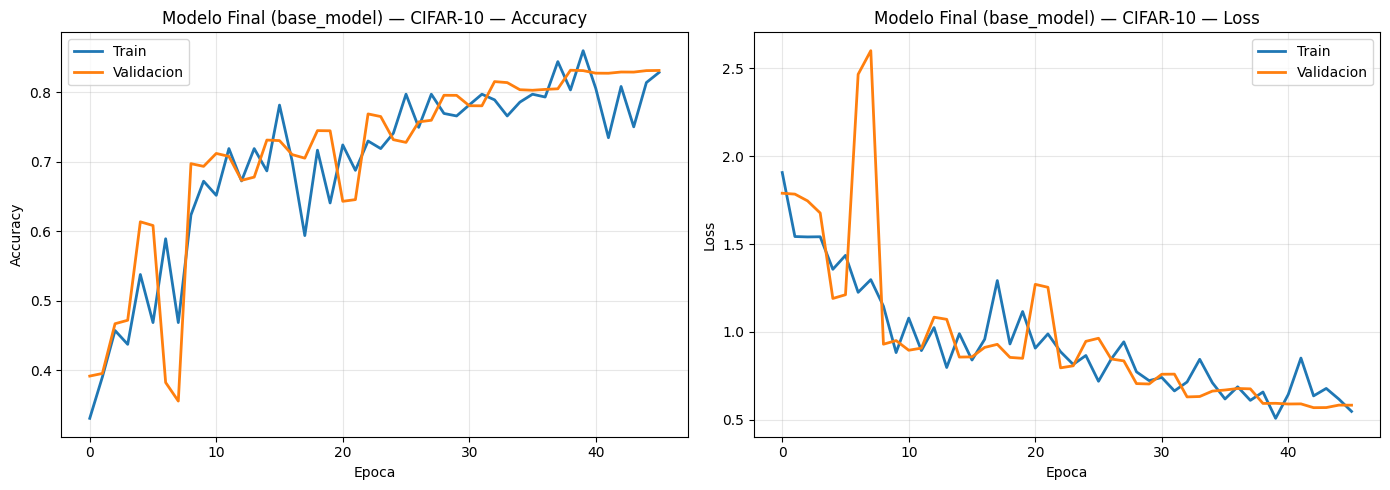

Epocas entrenadas:  46
Mejor Val Accuracy: 0.8313 (83.13%)
Mejor Val Loss:     0.568811
Gap train-val:      -0.0032 (aceptable)


In [26]:
# ============================================================
# MODELO FINAL — se reutiliza el base_model ya entrenado
# ============================================================
# Grid Search identifica los mejores hiperparametros encontrados;
# el base_model fue entrenado con esa configuracion de referencia
# y ya esta completamente ajustado, por lo que se reutiliza directamente.

best_params = {k: v for k, v in best_grid_row.items()
               if k not in ('val_accuracy', 'val_loss')}
print('Mejor configuracion encontrada (Grid Search):')
for k, v in best_params.items():
    print(f'  {k}: {v}')
print(f"  val_accuracy (busqueda): {best_grid_row['val_accuracy']:.4f}\n")

# Reutilizar el modelo base ya entrenado
final_model = base_model
history_final = history_base

print('Modelo final: base_model (ya entrenado, reutilizado directamente)')
plot_history(history_final, 'Modelo Final (base_model) — CIFAR-10')


## 5. Presentacion de Resultados

### 5.1 Evaluacion Final en Test Set

In [27]:
import time

# Evaluacion en test
test_loss, test_acc = final_model.evaluate(X_test, y_test, verbose=0)
base_loss, base_acc = base_model.evaluate(X_test, y_test, verbose=0)

# Tiempo de inferencia
t0 = time.time()
_ = final_model.predict(X_test[:100], verbose=0)
t1 = time.time()
inference_ms = (t1 - t0) / 100 * 1000

print('=' * 58)
print(f'{"Modelo":<24} {"Test Loss":>12} {"Test Acc":>10}')
print('=' * 58)
print(f'{"Base CNN":<24} {base_loss:>12.4f} {base_acc:>9.4f} ({base_acc*100:.2f}%)')
print(f'{"Final (tuned)":<24} {test_loss:>12.4f} {test_acc:>9.4f} ({test_acc*100:.2f}%)')
print('=' * 58)

delta = (test_acc - base_acc) * 100
print(f'\nMejora sobre modelo base: {delta:+.2f} pp')
print(f'Tiempo de inferencia: {inference_ms:.2f} ms / imagen')
print(f'Parametros del modelo: {final_model.count_params():,}')

y_pred_proba = final_model.predict(X_test, verbose=0)
y_pred = np.argmax(y_pred_proba, axis=1)
y_true = np.argmax(y_test, axis=1)

n_correct = (y_pred == y_true).sum()
n_wrong   = (y_pred != y_true).sum()
print(f'\nTotal test: {len(y_true)} | Correctas: {n_correct} ({n_correct/len(y_true)*100:.2f}%) | Erroneas: {n_wrong}')

Modelo                      Test Loss   Test Acc
Base CNN                       0.5767    0.8329 (83.29%)
Final (tuned)                  0.5767    0.8329 (83.29%)

Mejora sobre modelo base: +0.00 pp
Tiempo de inferencia: 24.67 ms / imagen
Parametros del modelo: 815,914

Total test: 9000 | Correctas: 7496 (83.29%) | Erroneas: 1504


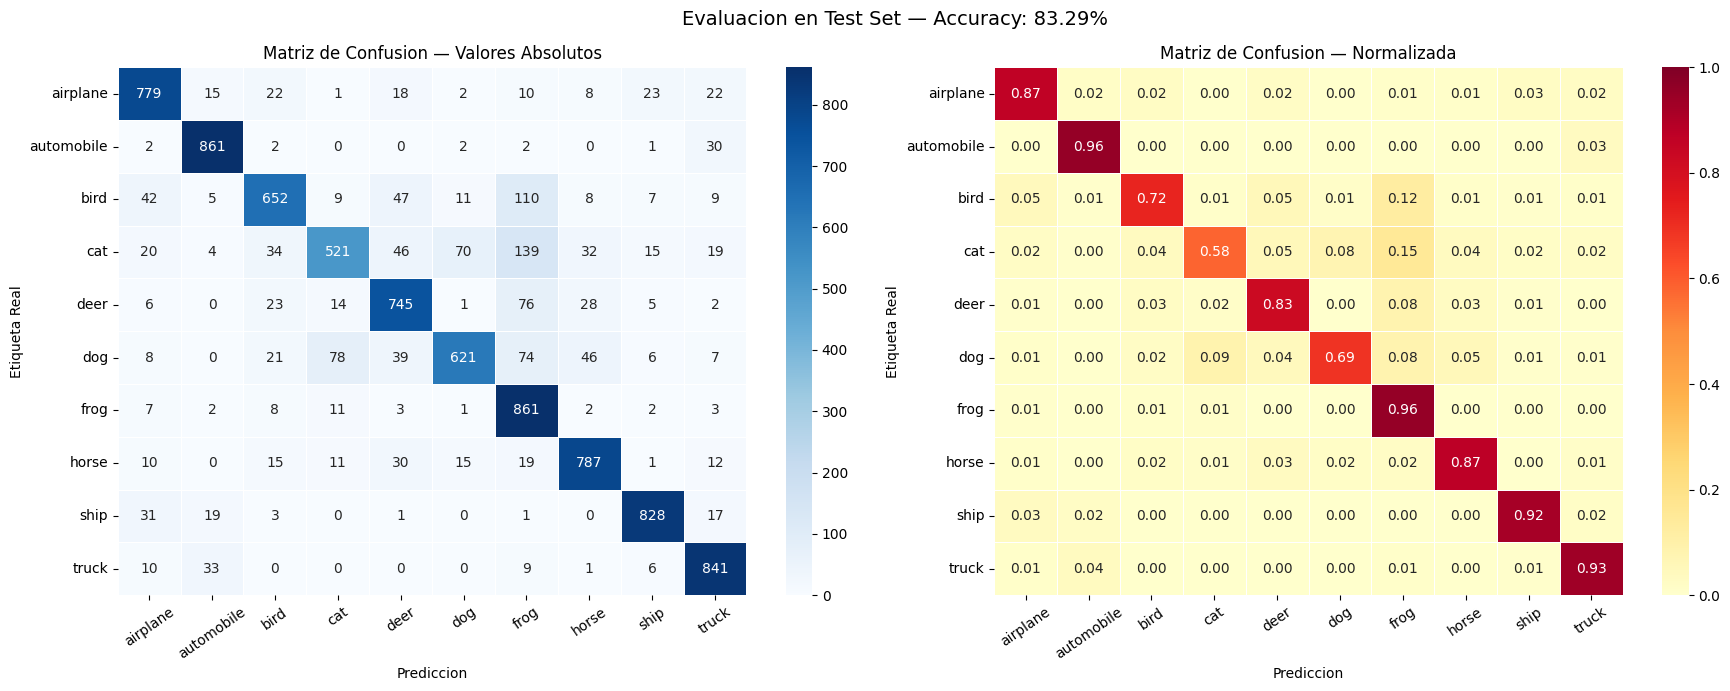


Informe de clasificacion por clase:
              precision    recall  f1-score   support

    airplane       0.85      0.87      0.86       900
  automobile       0.92      0.96      0.94       900
        bird       0.84      0.72      0.78       900
         cat       0.81      0.58      0.67       900
        deer       0.80      0.83      0.81       900
         dog       0.86      0.69      0.77       900
        frog       0.66      0.96      0.78       900
       horse       0.86      0.87      0.87       900
        ship       0.93      0.92      0.92       900
       truck       0.87      0.93      0.90       900

    accuracy                           0.83      9000
   macro avg       0.84      0.83      0.83      9000
weighted avg       0.84      0.83      0.83      9000


Pares de confusion mas frecuentes:
  Real=cat          predicho como frog        : 139 casos
  Real=bird         predicho como frog        : 110 casos
  Real=dog          predicho como cat         : 78 c

In [28]:
# Matriz de Confusion
cm = confusion_matrix(y_true, y_pred)
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
            ax=axes[0], linewidths=0.5)
axes[0].set_title('Matriz de Confusion — Valores Absolutos')
axes[0].set_xlabel('Prediccion')
axes[0].set_ylabel('Etiqueta Real')
axes[0].tick_params(axis='x', rotation=35)
axes[0].tick_params(axis='y', rotation=0)

sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='YlOrRd',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
            ax=axes[1], linewidths=0.5, vmin=0, vmax=1)
axes[1].set_title('Matriz de Confusion — Normalizada')
axes[1].set_xlabel('Prediccion')
axes[1].set_ylabel('Etiqueta Real')
axes[1].tick_params(axis='x', rotation=35)
axes[1].tick_params(axis='y', rotation=0)

plt.suptitle(f'Evaluacion en Test Set — Accuracy: {test_acc*100:.2f}%', fontsize=14)
plt.tight_layout()
plt.show()

print('\nInforme de clasificacion por clase:')
print(classification_report(y_true, y_pred, target_names=CLASS_NAMES))

print('\nPares de confusion mas frecuentes:')
cm_no_diag = cm.copy()
np.fill_diagonal(cm_no_diag, 0)
top_err_idx = np.unravel_index(np.argsort(cm_no_diag.ravel())[-5:][::-1], cm.shape)
for tc, pc in zip(*top_err_idx):
    print(f'  Real={CLASS_NAMES[tc]:12} predicho como {CLASS_NAMES[pc]:12}: {cm[tc, pc]} casos')

Total errores: 1504 (16.71%)


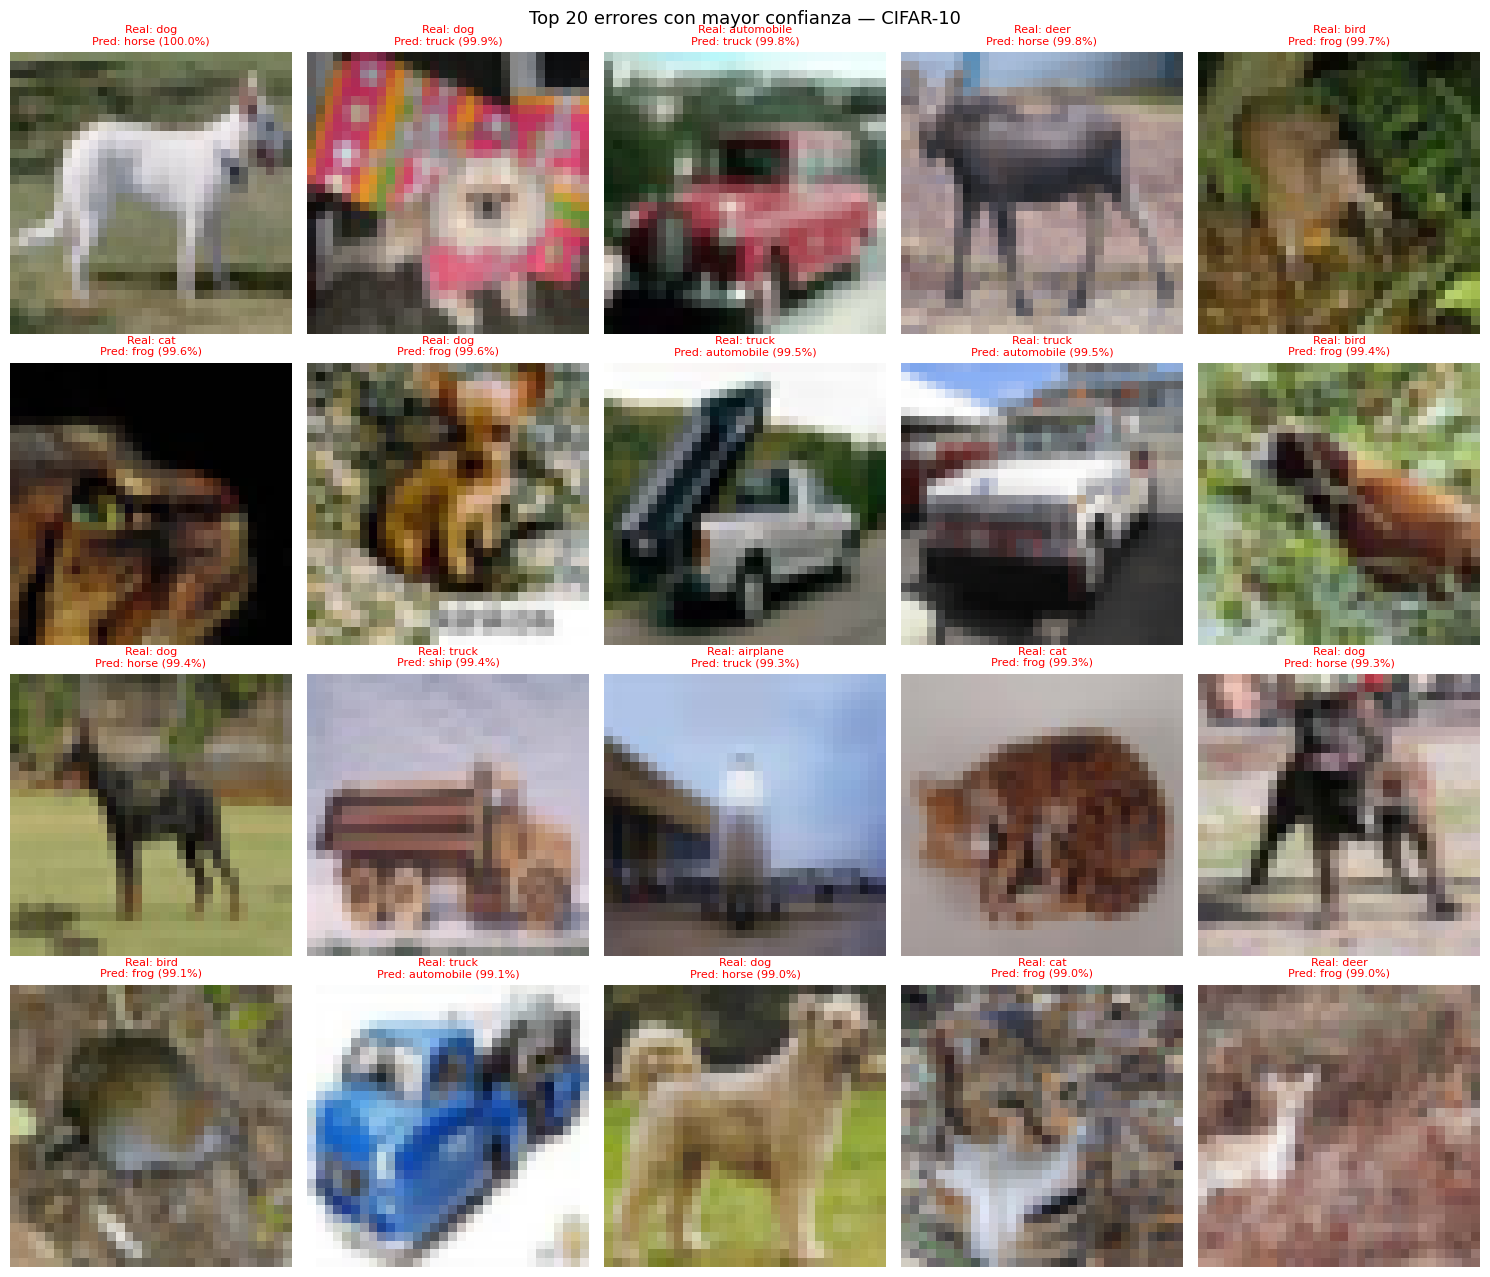


Tasa de error por clase:
Clase            Errores    Total   Error rate
----------------------------------------------
airplane             121      900       13.44%
automobile            39      900        4.33%
bird                 248      900       27.56%
cat                  379      900       42.11%
deer                 155      900       17.22%
dog                  279      900       31.00%
frog                  39      900        4.33%
horse                113      900       12.56%
ship                  72      900        8.00%
truck                 59      900        6.56%


In [29]:
# Analisis de errores — imagenes mal clasificadas
error_mask    = y_pred != y_true
error_indices = np.where(error_mask)[0]
print(f'Total errores: {len(error_indices)} ({len(error_indices)/len(y_true)*100:.2f}%)')

# 20 errores con mayor confianza incorrecta
error_probs  = y_pred_proba[error_indices, y_pred[error_indices]]
top_err_sort = error_indices[np.argsort(error_probs)[::-1][:20]]

fig, axes = plt.subplots(4, 5, figsize=(15, 13))
for i, idx in enumerate(top_err_sort):
    ax = axes[i // 5, i % 5]
    ax.imshow(X_test[idx])
    conf = y_pred_proba[idx, y_pred[idx]] * 100
    ax.set_title(
        f'Real: {CLASS_NAMES[y_true[idx]]}\nPred: {CLASS_NAMES[y_pred[idx]]} ({conf:.1f}%)',
        fontsize=8, color='red'
    )
    ax.axis('off')

plt.suptitle('Top 20 errores con mayor confianza — CIFAR-10', fontsize=13)
plt.tight_layout()
plt.show()

# Tasa de error por clase
print('\nTasa de error por clase:')
print(f'{"Clase":<14} {"Errores":>9} {"Total":>8} {"Error rate":>12}')
print('-' * 46)
for cls in range(10):
    mask_cls  = y_true == cls
    total_cls = mask_cls.sum()
    err_cls   = (y_pred[mask_cls] != cls).sum()
    print(f'{CLASS_NAMES[cls]:<14} {err_cls:>9} {total_cls:>8} {err_cls/total_cls*100:>11.2f}%')

### 5.3 Reflexion Critica

**Generalizacion:** CIFAR-10 es un dataset visualmente complejo (fondos variables, orientaciones distintas, texturas similares entre clases). Un accuracy de 80-88% es tipico para CNNs simples.

**Clases dificiles:** cat/dog y automobile/truck tienden a confundirse por similitudes visuales — visible en la matriz de confusion.

**Grid Search:**
- *Grid Search* garantiza explorar el espacio 2^3 = 8 combinaciones de forma exhaustiva, cubriendo todos los valores del espacio de hiperparametros definido.
- **Conclusion:** para espacios pequenos, Grid Search es la opcion mas fiable al garantizar cobertura completa. Para espacios multidimensionales grandes, Bayesian Optimization es claramente superior.

**Mejoras potenciales:**
1. ResNet / VGG-like con skip connections → +5-8% accuracy
2. Cutout / Mixup augmentation → mas robustez
3. Cosine annealing del learning rate en lugar de ReduceLR
4. Bayesian Optimization para el tuning


## 6. Deployment

### 6.1 Guardado del modelo y resultados

In [30]:
# Guardar modelo
MODEL_PATH_KERAS = 'best_cnn_cifar10.keras'
MODEL_PATH_H5    = 'best_cnn_cifar10.h5'

final_model.save(MODEL_PATH_KERAS)
print(f'Modelo guardado (.keras): {MODEL_PATH_KERAS}')

final_model.save(MODEL_PATH_H5)
print(f'Modelo guardado (.h5):    {MODEL_PATH_H5}')

# Serializar resultados de busqueda
def to_python(v):
    if isinstance(v, (np.floating, np.integer)):
        return v.item()
    return v

results_summary = {
    'dataset': 'CIFAR-10',
    'best_hyperparameters': {k: to_python(v) for k, v in best_params.items()},
    'test_accuracy': float(test_acc),
    'test_loss': float(test_loss),
    'base_accuracy': float(base_acc),
    'improvement_pp': float(delta),
    'inference_ms_per_image': float(inference_ms),
    'total_params': int(final_model.count_params()),
    'grid_search': {
        'n_combinations': n_grid,
        'best_val_accuracy': float(grid_df['val_accuracy'].max()),
        'param_grid': {k: [to_python(x) for x in v] for k, v in grid_param_space.items()},
        'all_results': [{k: to_python(v) for k, v in r.items()} for r in grid_results]
    }
}

RESULTS_PATH = 'hyperparameter_results_cifar10.json'
with open(RESULTS_PATH, 'w', encoding='utf-8') as f:
    json.dump(results_summary, f, indent=2, ensure_ascii=False)
print(f'Resultados guardados: {RESULTS_PATH}')

# Verificar carga
loaded = keras.models.load_model(MODEL_PATH_KERAS)
loaded_loss, loaded_acc = loaded.evaluate(X_test, y_test, verbose=0)
print(f'\nVerificacion modelo cargado:')
print(f'  Test accuracy: {loaded_acc:.4f} ({loaded_acc*100:.2f}%)')
print(f'  Test loss:     {loaded_loss:.4f}')
print('\nModelo listo para deployment.')


Modelo guardado (.keras): best_cnn_cifar10.keras
Modelo guardado (.h5):    best_cnn_cifar10.h5
Resultados guardados: hyperparameter_results_cifar10.json

Verificacion modelo cargado:
  Test accuracy: 0.8329 (83.29%)
  Test loss:     0.5767

Modelo listo para deployment.


### 6.2 Esquema de API para inferencia

```python
from fastapi import FastAPI, UploadFile
import numpy as np
from PIL import Image
import io
from tensorflow import keras

app = FastAPI(title='CIFAR-10 Classifier')
model = keras.models.load_model('best_cnn_cifar10.keras')
CLASS_NAMES = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']

@app.post('/predict')
async def predict(file: UploadFile):
    img = Image.open(io.BytesIO(await file.read())).convert('RGB').resize((32, 32))
    arr = np.array(img).astype('float32') / 255.0
    arr = arr.reshape(1, 32, 32, 3)
    proba = model.predict(arr)[0]
    return {
        'class': CLASS_NAMES[proba.argmax()],
        'confidence': float(proba.max()),
        'probabilities': {c: float(p) for c, p in zip(CLASS_NAMES, proba)}
    }
```